# Komunitas Graph FB

## Liberary

In [ ]:
import networkx as nx
from community import community_louvain  # python-louvain
import matplotlib.pyplot as plt

## LOAD DATA

In [ ]:
file_path = "facebook_combined.txt"
G = nx.read_edgelist(file_path, nodetype=int)

print("Jumlah Node :", G.number_of_nodes())
print("Jumlah Edge :", G.number_of_edges())

Jumlah Node : 4039
Jumlah Edge : 88234


## JUMLAH KOMUNITAS

In [ ]:
partition = community_louvain.best_partition(G)

# Jumlah komunitas
num_communities = len(set(partition.values()))
print("Jumlah Komunitas Terdeteksi:", num_communities)

Jumlah Komunitas Terdeteksi: 15


## MODULARITY

In [ ]:
modularity = community_louvain.modularity(partition, G)
print("Modularity:", modularity)

Modularity: 0.8348139684208291


## ANGGOTA KOMUNITAS

In [ ]:
for comm_id, members in community_groups.items():
    subG = G.subgraph(members)

    print(f"\nKomunitas {comm_id} | Jumlah anggota: {len(members)}")
    print(members)


Komunitas 0 | Jumlah anggota: 344
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 22

## ANGGOTA TERBANYAK

In [ ]:
community_groups = defaultdict(list)
for node, comm_id in partition.items():
    community_groups[comm_id].append(node)

In [ ]:
largest_comm_id = max(community_groups, key=lambda c: len(community_groups[c]))
largest_nodes = community_groups[largest_comm_id]

print("ID komunitas terbesar   :", largest_comm_id)
print("Jumlah anggota komunitas:", len(largest_nodes))

# Ambil subgraph komunitas terbesar
G_big = G.subgraph(largest_nodes)

ID komunitas terbesar   : 9
Jumlah anggota komunitas: 548


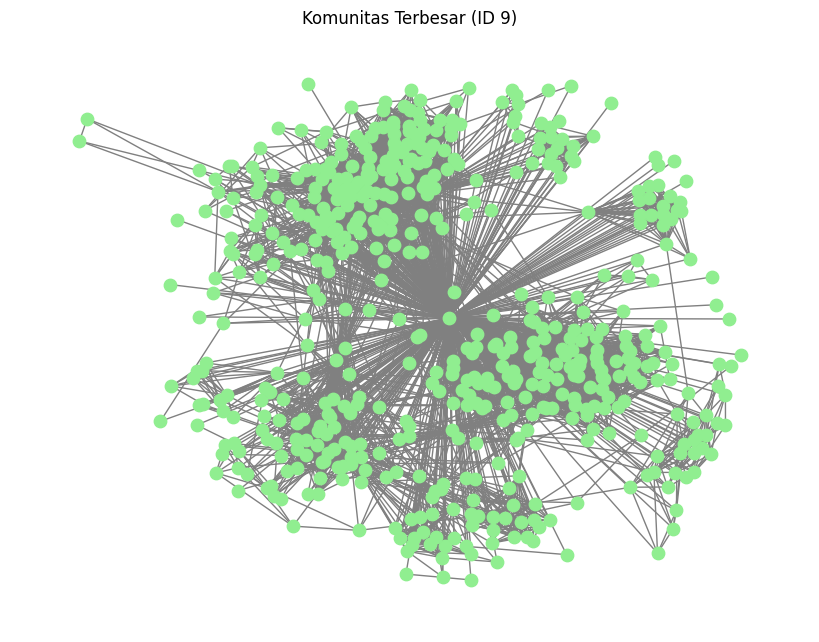

In [ ]:
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G_big, seed=42)
nx.draw(G_big, pos, node_color="lightgreen", node_size=80, edge_color="gray", with_labels=False)
plt.title(f"Komunitas Terbesar (ID {largest_comm_id})")
plt.show()

## SUB KOMUNITAS DI DALAM KOMUNITAS

In [ ]:
from collections import defaultdict

sub_partition = community_louvain.best_partition(G_big)

# kelompokkan hasil sub-komunitas
sub_groups = defaultdict(list)
for node, cid in sub_partition.items():
    sub_groups[cid].append(node)

print("\n===== SUB-KOMUNITAS DALAM KOMUNITAS TERBESAR =====")
for cid, members in sub_groups.items():
    print(f"Sub-komunitas {cid} | Jumlah anggota: {len(members)}")


===== SUB-KOMUNITAS DALAM KOMUNITAS TERBESAR =====
Sub-komunitas 0 | Jumlah anggota: 143
Sub-komunitas 4 | Jumlah anggota: 121
Sub-komunitas 3 | Jumlah anggota: 42
Sub-komunitas 5 | Jumlah anggota: 54
Sub-komunitas 1 | Jumlah anggota: 133
Sub-komunitas 2 | Jumlah anggota: 19
Sub-komunitas 6 | Jumlah anggota: 22
Sub-komunitas 7 | Jumlah anggota: 14


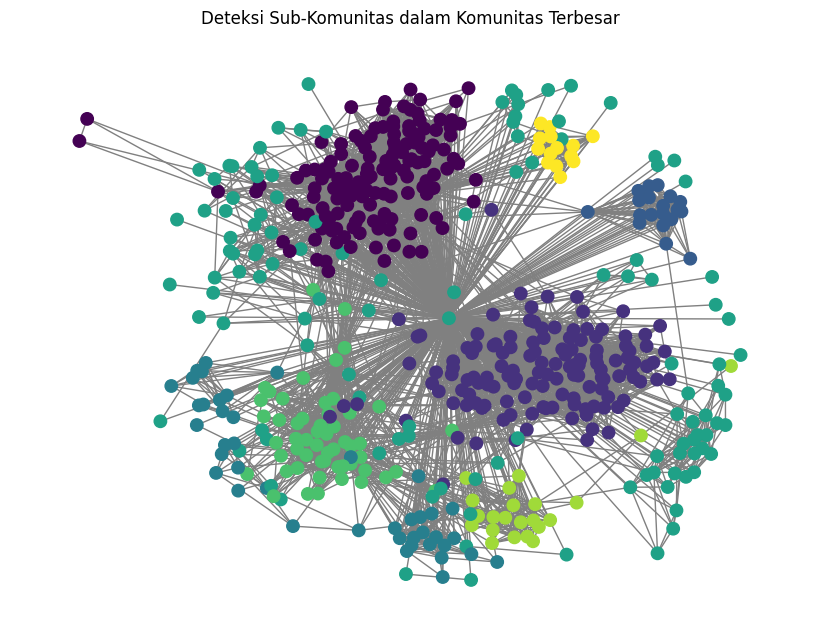

In [ ]:
plt.figure(figsize=(8, 6))
colors = [sub_partition[node] for node in G_big.nodes()]
nx.draw(G_big, pos, node_color=colors, node_size=80, edge_color="gray", with_labels=False)
plt.title("Deteksi Sub-Komunitas dalam Komunitas Terbesar")
plt.show()

## VIASUALISASI KESELURUHAN

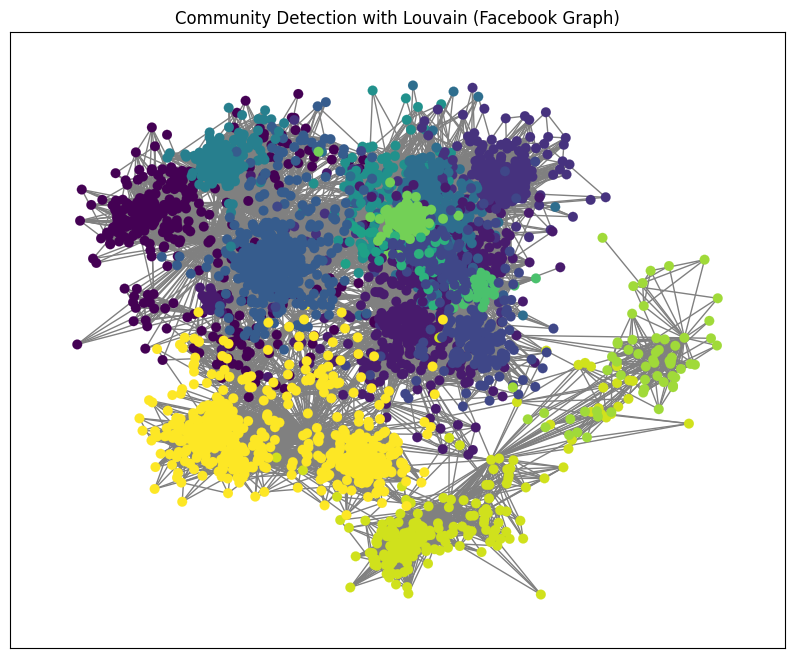

In [ ]:
sample_nodes = list(G.nodes())[:5000]
H = G.subgraph(sample_nodes)

pos = nx.spring_layout(H, seed=42)
colors = [partition[n] for n in H.nodes()]

plt.figure(figsize=(10, 8))
nx.draw_networkx(H, pos,
                 node_color=colors,
                 node_size=50,
                 edge_color='gray',
                 linewidths=0.1,
                 with_labels=False)

plt.title("Community Detection with Louvain (Facebook Graph)")
plt.show()